# Mixed Effects Models

## Overview

Mixed effects models (multilevel/hierarchical models) handle grouped or nested data by partitioning variance into fixed effects (population-level) and random effects (group-level deviations). Python's `statsmodels.mixedlm` and `pymer4` (wrapping R's `lme4`) are the main tools.

**When to use mixed effects:**
- Repeated measures on the same subject/site
- Observations nested within groups (sites within catchments)
- You want to generalise to new groups not in the data

**Fixed vs random effects:**

| Effect | Estimates | Use when |
|---|---|---|
| Fixed | Specific level means | Levels are the population of interest |
| Random | Distribution of deviations | Levels are a sample from a larger population |

**Note on Python vs R:** `statsmodels.mixedlm` handles random intercepts and slopes well for Gaussian outcomes. For GLMMs (binary, count outcomes), `pymer4` (R's `lme4` via rpy2) or `glmmTMB` are substantially more capable than pure Python alternatives.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

rng = np.random.default_rng(42)
# Nested: 150 sites within 10 catchments, 3 repeated measurements each
n_catchments = 10
n_sites_per  = 15
n_repeats    = 3
catchment_effects = rng.normal(0, 4, n_catchments)  # random intercepts
rows = []
for c in range(n_catchments):
    for s in range(n_sites_per):
        site_effect = rng.normal(0, 2)
        elevation   = rng.uniform(50, 350)
        for t in range(n_repeats):
            nitrate = rng.gamma(2, 2)
            richness = (22 + catchment_effects[c] + site_effect
                        - 0.03*elevation - 0.6*nitrate
                        + rng.normal(0, 2))
            rows.append(dict(catchment=f'C{c+1}', site=f'C{c+1}S{s+1}',
                             repeat=t+1, elevation=elevation,
                             nitrate=nitrate, richness=richness))
df = pd.DataFrame(rows)
print(f"Shape: {df.shape}")
print(df.groupby('catchment')['richness'].mean().round(2))

Shape: (450, 6)
catchment
C1     13.62
C10     9.16
C2      9.56
C3     14.67
C4     16.28
C5      6.11
C6      7.16
C7     15.68
C8     10.80
C9     14.16
Name: richness, dtype: float64


---
## Random Intercept Model

In [2]:
# Random intercept: each site gets its own intercept
# Groups = site (repeated measures within site)
ri_model = smf.mixedlm(
    "richness ~ elevation + nitrate",
    data=df,
    groups=df["site"]   # random intercept per site
).fit(reml=True)
print(ri_model.summary())
print(f"\nRandom effects variance (between-site): {ri_model.cov_re.values[0,0]:.3f}")
print(f"Residual variance (within-site):        {ri_model.scale:.3f}")
ICC = ri_model.cov_re.values[0,0] / (ri_model.cov_re.values[0,0] + ri_model.scale)
print(f"ICC: {ICC:.3f}  ({ICC:.0%} of variance is between-site)")

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: richness  
No. Observations: 450     Method:             REML      
No. Groups:       150     Scale:              4.0043    
Min. group size:  3       Log-Likelihood:     -1148.5208
Max. group size:  3       Converged:          Yes       
Mean group size:  3.0                                   
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept    18.984    0.883  21.504 0.000 17.254 20.714
elevation    -0.025    0.004  -6.215 0.000 -0.032 -0.017
nitrate      -0.565    0.038 -14.790 0.000 -0.640 -0.490
Group Var    15.983    1.231                            


Random effects variance (between-site): 15.983
Residual variance (within-site):        4.004
ICC: 0.800  (80% of variance is between-site)


---
## Random Intercept + Random Slope

In [3]:
# Random slope: nitrate effect varies by site
rs_model = smf.mixedlm(
    "richness ~ elevation + nitrate",
    data=df,
    groups=df["site"],
    re_formula="~nitrate"   # random slope for nitrate
).fit(reml=True)
print(rs_model.summary())
# Extract random effects for each site
re_df = pd.DataFrame(
    {site: vals.values for site, vals in rs_model.random_effects.items()},
    index=['intercept', 'nitrate_slope']
).T.head(10)
print("\nRandom effects (first 10 sites):")
print(re_df.round(3))

c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


            Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   richness  
No. Observations:   450       Method:               REML      
No. Groups:         150       Scale:                2.8024    
Min. group size:    3         Log-Likelihood:       -1263.0710
Max. group size:    3         Converged:            No        
Mean group size:    3.0                                       
--------------------------------------------------------------
                    Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------
Intercept           19.018    0.846 22.468 0.000 17.359 20.677
elevation           -0.026    0.004 -6.725 0.000 -0.033 -0.018
nitrate             -0.448    0.142 -3.155 0.002 -0.727 -0.170
Group Var           10.750    1.034                           
Group x nitrate Cov  0.659    0.480                           
nitrate Var          2.590                                    


Ran

c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 119.108968
  warnings.warn(msg, ConvergenceWarning)
c:\Users\saman\Documents\Repos\python_methods_library\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.war

---
## Nested Random Effects: Sites within Catchments

Catchment-level random intercepts:
            Coef. Std.Err.        z  P>|z|  [0.025  0.975]
Intercept  19.598    1.206   16.257  0.000  17.235  21.961
elevation  -0.027    0.002  -16.512  0.000  -0.030  -0.024
nitrate    -0.588    0.046  -12.867  0.000  -0.678  -0.499
Group Var  12.883    2.170                                

Between-catchment SD: 3.589
Residual SD:           2.867


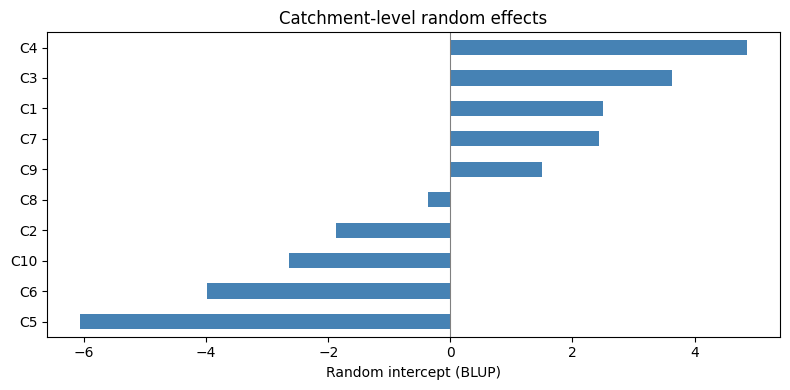

In [4]:
# Two-level nesting: site within catchment
# statsmodels handles crossed/nested via groups + variance components
nested = smf.mixedlm(
    "richness ~ elevation + nitrate",
    data=df,
    groups=df["catchment"],          # top-level grouping
    re_formula="~1",
).fit(reml=True)
print("Catchment-level random intercepts:")
print(nested.summary().tables[1])
print(f"\nBetween-catchment SD: {np.sqrt(nested.cov_re.values[0,0]):.3f}")
print(f"Residual SD:           {np.sqrt(nested.scale):.3f}")
# Visualise: BLUPs (Best Linear Unbiased Predictors)
blups = pd.Series({c: v['Group'] for c, v in nested.random_effects.items()},
                   name='BLUP')
fig, ax = plt.subplots(figsize=(8,4))
blups.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('Random intercept (BLUP)')
ax.set_title('Catchment-level random effects')
plt.tight_layout(); plt.show()

In [5]:
# Model comparison: random intercept vs fixed effects only
fixed_only = smf.ols("richness ~ elevation + nitrate", data=df).fit()
ri_ml = smf.mixedlm("richness ~ elevation + nitrate",
                     data=df, groups=df["site"]).fit(reml=False)  # ML for LRT
print(f"Fixed-only  AIC: {fixed_only.aic:.2f}")
print(f"Random int  AIC: {ri_ml.aic:.2f}")
# Likelihood ratio test
LRT_stat = -2 * (fixed_only.llf - ri_ml.llf)
# Boundary test: chi2 mixture (df=1 but boundary so p/2)
LRT_p = 0.5 * stats.chi2.sf(LRT_stat, df=1)
print(f"LRT statistic: {LRT_stat:.3f}")
print(f"LRT p-value (boundary corrected): {LRT_p:.4f}")
print("p < 0.05 -> random intercept significantly improves fit")
print("\nNote: use REML=True for final parameter estimates,")
print("      REML=False (ML) only when comparing fixed effect structures")

Fixed-only  AIC: 2623.81
Random int  AIC: 2292.79
LRT statistic: 335.021
LRT p-value (boundary corrected): 0.0000
p < 0.05 -> random intercept significantly improves fit

Note: use REML=True for final parameter estimates,
      REML=False (ML) only when comparing fixed effect structures


---

## Common Pitfalls

**1. Comparing fixed vs random effects models with REML**  
REML (Restricted Maximum Likelihood) should be used for estimating variance components but cannot be used to compare models with different fixed effects structures. Use ML (REML=False) for likelihood ratio tests comparing fixed effects; switch back to REML for the final model.

**2. Using a fixed effect for catchment when the goal is generalisation**  
If you fit a fixed effect for each catchment, you estimate each catchment's mean exactly but cannot generalise to new catchments. Use a random effect when catchments are a sample from a broader population of possible catchments.

**3. Ignoring the ICC before deciding whether mixed effects are needed**  
If the ICC is near zero, grouping explains negligible variance and a simple regression may suffice. If ICC > 0.1, ignoring the grouping structure underestimates standard errors and inflates Type I error substantially.

**4. Fitting GLMMs (binary/count outcomes) with statsmodels.mixedlm**  
`statsmodels.mixedlm` is designed for Gaussian outcomes only. Applying it to binary or count data is incorrect. Use `pymer4` (wrapping `lme4`) or `glmmTMB` via rpy2 for non-Gaussian GLMMs in Python.

**5. Over-specifying the random effects structure with small samples**  
Fitting random slopes for every predictor requires many groups and observations per group to estimate reliably. A maximal random effects structure with insufficient data produces singular fits and unreliable variance estimates. Start with random intercepts; add random slopes only when the data support them.
---
*python_methods_library - Samantha McGarrigle*